In [1]:
# modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import h5py
import pandas as pd
from datetime import datetime, timedelta, timezone
from scipy.signal import welch, hilbert, correlate, spectrogram, resample, decimate
from scipy.optimize import curve_fit
plt.rcParams['text.usetex']=False

In [2]:
# filename = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250815/Y1_RDS-OUTS_V1_MON_OUT_DQ_1439330160_1439344560.h5' # J electrode output
# filename = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250815/Y1_RDS-LES_YAW_MON_OUT_DQ_1439330160_1439344560.h5' # Yaw with electrode output
filename = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250801/Y1_RDS-LES_YAW_MON_OUT_DQ_1437819028_1438164628.h5' # beamsplitter; change in power
# filename = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250730/Y1_RDS-LES_YAW_MON_OUT_DQ_1436896818_1437760818.h5' # stability; +week long data in chunks

In [3]:
with h5py.File(filename, "r") as f:
    def print_hdf5_structure(name, obj):
        print(name)

    f.visititems(print_hdf5_structure)

data
segments
segments/gps_start
segments/index_start
segments/length


### For segmented h5 files using nds2 fetch

##### Plot raw data

In [ ]:
# Dealing with large amounts of raw data by downsampling - changing to include decimate with chebyshev filter

# constants
fs_target = 200.0 # choose new target sampling rate (Hz) for downsampling - may be slightly different based on original sample rate
# max_points = 200_000 # maximum number of points to plot - change as needed
GPS_UNIX_OFFSET = 315964800 - 18 # GPS time offset for UTC conversion

# UTC window of interest
start_time = None # datetime(2025, 8, 28, 21, 0, 0, tzinfo=timezone.utc)
end_time = None #datetime(2025, 8, 29, 1, 0, tzinfo=timezone.utc)

# Load and process raw data
with h5py.File(filename, 'r') as f:
    data = f['data']
    segment_starts = f['segments/index_start'][:]
    segment_lengths = f['segments/length'][:]
    gps_times = f['segments/gps_start'][:]
    sample_rate = float(f.attrs['sample_rate'])
    dt = 1.0 / sample_rate

    total_samples = int(data.shape[0]) # total number of samples

    # step = max(1, total_samples // max_points) # step size for downsampling (deal with large amounts of data) & no downsampling if total_samples < max_points

    # print(f"Total samples: {total_samples}")
    print(f"Sample rate: {sample_rate} Hz")
    # print(f"Decimation step: {step}") 

    # Build arrays nby collecting all segments
    t_list = [] # time values 
    y_list = [] # amplitude values 

    for i in range(len(segment_starts)): # iterate over each segment
        start = int(segment_starts[i]) # segment start index
        n = int(segment_lengths[i]) # number of samples in this segment
        if n <= 0:
            continue # skip any empty segments

        y_seg = data[start:start+n]
        t_seg = gps_times[i] + np.arange(n) * dt
        t_list.append(t_seg)
        y_list.append(y_seg)

        if not t_list: # if no data collected, skip
            raise ValueError("No data collected from file segments.")

        # Calculate which samples to take from this segment
        # r = (-start) % step # calculate remainder to align with step/where to start sampling
        # seg_indices = np.arange(start + r, start + n, step, dtype=np.int64) # keeps segment consistency across file
        # if seg_indices.size == 0:
        #     continue 

        t_full = np.concatenate(t_list)
        y_full = np.concatenate(y_list)

        if start_time is not None and end_time is not None:
            t_start = (start_time.timestamp() - GPS_UNIX_OFFSET)
            t_end   = (end_time.timestamp()   - GPS_UNIX_OFFSET)
            mask = (t_full >= t_start) & (t_full <= t_end)
            t_full = t_full[mask]
            y_full = y_full[mask]
        if y_full.size == 0:
            raise ValueError("No data in the specified time window.")

        # Decimate data to target sampling rate
        q = max(1, int(sample_rate / fs_target)) # downsampling factor from target sampling rate
        fs_effective = sample_rate / q # effective sampling rate after downsampling
        #print(f"Decimating by factor {q} to effective sampling rate {fs_effective:.2f} Hz")

        y_ds = decimate(y_full, q, ftype="iir", zero_phase=True) # use decimate with cheby filter
        t_0 = t_full[0] # initial time for offset
        t_ds = t_0 + np.arange(y_ds.shape[0], dtype=np.float64) * (1.0 / fs_effective) # new time array based on effective sampling rate
        # t_ds = t_full[::q] # this is off by 1...?

        # Aliasing safety check!! 
        nyquist = fs_effective / 2.0 # Nyquist frequency is half the sampling rate
        expected_drive_freq = None # set if known
        if expected_drive_freq and expected_drive_freq > nyquist:
            print(f"WARNING: {filename} — Expected drive {expected_drive_freq:.2f} Hz "
                    f"is above Nyquist {nyquist:.2f} Hz (aliasing risk).")

        # # Decimated samples
        # y_seg = data[seg_indices]
        
        # Calculate time for each sample
        # t_seg = gps_times[i] + (seg_indices - start).astype(np.float64) * dt

        # Convert GPS to datetime
        t_plot = [datetime.fromtimestamp(tt + GPS_UNIX_OFFSET, tz=timezone.utc) 
                     for tt in t_ds]
        
        # t_plot.extend(t_datetime)
        # y_plot.extend(y_seg.astype(np.float32))

plt.figure(figsize=(10, 6))
plt.plot(t_plot, y_ds, linewidth=0.6, alpha=0.8)
plt.xlabel('Time (UTC)')
plt.ylabel('Amplitude')
plt.title('Raw Time Series Data')

# # set x-axis range
# start_time = datetime(2025, 8, 15, 21, 50, 0, tzinfo=timezone.utc) 
# end_time = datetime(2025, 8, 15, 23, 0, 0, tzinfo=timezone.utc)   
# plt.xlim(start_time, end_time)

# time formatting for better axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print(f"Plotted {len(y_plot)} points")

Sample rate: 1024.0 Hz


In [12]:
# Dealing with large amounts of raw data by downsampling - changing to include decimate with chebyshev filter

# constants
# fs_target = 200.0 # choose new target sampling rate (Hz) for downsampling - may be slightly different based on original sample rate
max_points = 250_000 # maximum number of points to plot - change as needed
GPS_UNIX_OFFSET = 315964800 - 18 # GPS time offset for UTC conversion

# UTC window of interest
start_time = None # datetime(2025, 8, 28, 21, 0, 0, tzinfo=timezone.utc)
end_time = None #datetime(2025, 8, 29, 1, 0, tzinfo=timezone.utc)

# Load and process raw data
with h5py.File(filename, 'r') as f:
    data = f['data']
    segment_starts = f['segments/index_start'][:]
    segment_lengths = f['segments/length'][:]
    gps_times = f['segments/gps_start'][:]
    sample_rate = float(f.attrs['sample_rate'])
    dt = 1.0 / sample_rate

    total_samples = int(data.shape[0]) # total number of samples

    step = max(1, total_samples // max_points) # step size for downsampling (deal with large amounts of data) & no downsampling if total_samples < max_points

    print(f"Total samples: {total_samples}")
    print(f"Sample rate: {sample_rate} Hz")
    print(f"Decimation step: {step}") 

    # Build arrays nby collecting all segments
    t_plot = [] # time values 
    y_plot = [] # amplitude values 

    for i in range(len(segment_starts)): # iterate over each segment
        start = int(segment_starts[i]) # segment start index
        n = int(segment_lengths[i]) # number of samples in this segment
        if n <= 0:
            continue # skip any empty segments

        # y_seg = data[start:start+n]
        # t_seg = gps_times[i] + np.arange(n) * dt
        # t_plot.append(t_seg)
        # y_plot.append(y_seg)

        # if not t_plot: # if no data collected, skip
        #     raise ValueError("No data collected from file segments.")

        # Calculate which samples to take from this segment
        r = (-start) % step # calculate remainder to align with step/where to start sampling
        seg_indices = np.arange(start + r, start + n, step, dtype=np.int64) # keeps segment consistency across file
        if seg_indices.size == 0:
            continue 

        t_plot = np.concatenate(t_list)
        y_plot = np.concatenate(y_list)

        if start_time is not None and end_time is not None:
            t_start = (start_time.timestamp() - GPS_UNIX_OFFSET)
            t_end   = (end_time.timestamp()   - GPS_UNIX_OFFSET)
            mask = (t_full >= t_start) & (t_full <= t_end)
            t_full = t_full[mask]
            y_full = y_full[mask]
        if y_full.size == 0:
            raise ValueError("No data in the specified time window.")

        # # Decimate data to target sampling rate
        # q = max(1, int(sample_rate / fs_target)) # downsampling factor from target sampling rate
        # fs_effective = sample_rate / q # effective sampling rate after downsampling
        # #print(f"Decimating by factor {q} to effective sampling rate {fs_effective:.2f} Hz")

        # y_ds = decimate(y_full, q, ftype="iir", zero_phase=True) # use decimate with cheby filter
        # t_0 = t_full[0] # initial time for offset
        # t_ds = t_0 + np.arange(y_ds.shape[0], dtype=np.float64) * (1.0 / fs_effective) # new time array based on effective sampling rate
        # # t_ds = t_full[::q] # this is off by 1...?

        # Aliasing safety check!! 
        # nyquist = fs_effective / 2.0 # Nyquist frequency is half the sampling rate
        # expected_drive_freq = None # set if known
        # if expected_drive_freq and expected_drive_freq > nyquist:
        #     print(f"WARNING: {filename} — Expected drive {expected_drive_freq:.2f} Hz "
        #             f"is above Nyquist {nyquist:.2f} Hz (aliasing risk).")

        # Decimated samples
        y_seg = data[seg_indices]
        
        # Calculate time for each sample
        t_seg = gps_times[i] + (seg_indices - start).astype(np.float64) * dt

        # Convert GPS to datetime
        t_plot = [datetime.fromtimestamp(tt + GPS_UNIX_OFFSET, tz=timezone.utc)
                   for tt in t_seg]
        
        t_plot.extend(t_datetime)
        y_plot.extend(y_seg.astype(np.float32))

plt.figure(figsize=(10, 6))
plt.plot(t_plot, y_plot, linewidth=0.6, alpha=0.8)
plt.xlabel('Time (UTC)')
plt.ylabel('Amplitude')
plt.title('Raw Time Series Data')

# # set x-axis range
# start_time = datetime(2025, 8, 15, 21, 50, 0, tzinfo=timezone.utc) 
# end_time = datetime(2025, 8, 15, 23, 0, 0, tzinfo=timezone.utc)   
# plt.xlim(start_time, end_time)

# time formatting for better axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print(f"Plotted {len(y_plot)} points")

Total samples: 353861632
Sample rate: 1024.0 Hz
Decimation step: 1415


AttributeError: 'numpy.ndarray' object has no attribute 'extend'

In [11]:
from fractions import Fraction
from scipy.signal import resample_poly  # faster, FIR anti-alias
import matplotlib.dates as mdates
from datetime import timezone, datetime

fs_target = 200.0
GPS_UNIX_OFFSET = 315964800 - 18

start_time = None
end_time   = None

with h5py.File(filename, 'r') as f:
    data = f['data']
    segment_starts = f['segments/index_start'][:]
    segment_lengths = f['segments/length'][:]
    gps_times = f['segments/gps_start'][:]
    fs_orig = float(f.attrs['sample_rate'])
    dt = 1.0 / fs_orig

    # rational approximation of fs_target
    ratio = Fraction(fs_target / fs_orig).limit_denominator(1000)
    up, down = ratio.numerator, ratio.denominator
    fs_achieved = fs_orig * up / down
    print(f"fs_target={fs_target:.6f} Hz → fs_achieved={fs_achieved:.6f} Hz (up={up}, down={down})")

    # optional window bounds as epoch seconds (GPS epoch)
    if start_time and end_time:
        t_start = start_time.timestamp() - GPS_UNIX_OFFSET
        t_end   = end_time.timestamp()   - GPS_UNIX_OFFSET
    else:
        t_start = -np.inf
        t_end   =  np.inf

    # collect already-downsampled pieces
    t_nums = []   # matplotlib date numbers (days)
    y_ds_list = []

    for i in range(len(segment_starts)):
        start = int(segment_starts[i])
        n = int(segment_lengths[i])
        if n <= 0:
            continue

        # compute segment time range to skip reads quickly
        seg_t0 = gps_times[i]
        seg_t1 = seg_t0 + (n - 1) * dt
        if seg_t1 < t_start or seg_t0 > t_end:
            continue  # fully outside window

        # read just this segment
        y_seg = np.asarray(data[start:start+n], dtype=np.float64)

        # trim to the desired time window before filtering/resampling (smaller arrays = faster)
        if np.isfinite(t_start) or np.isfinite(t_end):
            # in-segment mask
            idx0 = max(0, int(np.floor((t_start - seg_t0) * fs_orig))) if np.isfinite(t_start) else 0
            idx1 = min(n, 1 + int(np.ceil((t_end - seg_t0) * fs_orig)))  if np.isfinite(t_end)   else n
            idx0 = max(0, min(idx0, n))
            idx1 = max(0, min(idx1, n))
            if idx1 <= idx0:
                continue
            y_seg = y_seg[idx0:idx1]
            seg_t0 = seg_t0 + idx0 * dt
            n = y_seg.size
            if n == 0:
                continue

        # polyphase resample with built-in lowpass
        y_res = resample_poly(y_seg, up, down)

        # vectorized time base for this resampled segment
        t_seg_res = seg_t0 + np.arange(y_res.size, dtype=np.float64) / fs_achieved

        # convert to matplotlib date numbers (fast) — no Python datetime loop
        t_nums.append(posix_to_num(t_seg_res + GPS_UNIX_OFFSET))

        y_ds_list.append(y_res.astype(np.float32))

# concatenate once
if not y_ds_list:
    raise RuntimeError("No samples to plot (check window or inputs).")

t_nums = np.concatenate(t_nums)
y_ds   = np.concatenate(y_ds_list)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot_date(t_nums, y_ds, '-', linewidth=0.6, alpha=0.8)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Amplitude')
ax.set_title('Raw Time Series Data (downsampled)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M', tz=timezone.utc))
fig.autofmt_xdate()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Plotted {y_ds.size} points at fs≈{fs_achieved:.3f} Hz")


fs_target=200.000000 Hz → fs_achieved=200.000000 Hz (up=25, down=128)


NameError: name 'posix_to_num' is not defined

In [26]:
# parameters for the PSD
window = 100.0  # seconds, FFT window length, freq resolution = 1/window
band = (0.0, 10.0) # Hz, band of interest for the PSD
dt_cut = datetime(2025, 8, 1, 0, 0, 0, tzinfo=timezone.utc)  # cut-off date for the PSD based on amplitude drop for 10 day window
fs = 1024.0
dt = 1.0/fs

In [ ]:
# Focus on region of interest manually - dominant frequency peaks
# Should adapt script later to auto-find regions especially when stepping in optical power

overlap = 0.5
# win_sec = 20.0
fs_target = 200.0 # choose new target sampling rate (Hz) for downsampling

# UTC window of interest
start_time = datetime(2025, 7, 30, 20, 2, 0, tzinfo=timezone.utc) #(2025, 7, 30, 19, 0, 0, tzinfo=timezone.utc)
end_time   = datetime(2025, 7, 30, 21, 30, 0, tzinfo=timezone.utc) #(2025, 7, 30, 22, 0, 0, tzinfo=timezone.utc)

with h5py.File(filename, "r") as f:
    idx = f["segments/index_start"][:].astype(np.int64)
    length = f["segments/length"][:].astype(np.int64)
    t0 = f["segments/gps_start"][:].astype(np.float64)  # GPS seconds
    fs = float(f.attrs["sample_rate"])

dt = 1.0 / fs  # sampling interval [s]

# Ensure chronological order by segment start time
order = np.argsort(t0)
idx, length, t0 = idx[order], length[order], t0[order]

# FFT params
N = int(round(win_sec * fs))  # samples per window
if N < 2:
    raise ValueError("win_sec too small for the sample rate.")

step = max(1, int(round(N * (1.0 - overlap))))  # hop size in samples depending on overlap -- can set overlap very low
win = np.hanning(N).astype(np.float64) # Apply Hann window to reduce spectral leakage artifacts at edges of each window 
# win = np.ones(N, dtype=np.float64) 

# rFFT (Hz)
freqs = np.fft.rfftfreq(N, d=dt)
fmin, fmax = band
band_mask = (freqs >= fmin) & (freqs <= fmax)
if not np.any(band_mask):
    raise ValueError("Band not on FFT grid; adjust win_sec or band.")
f_band = freqs[band_mask]
df = freqs[1] - freqs[0] # nominal bin spacing (~ 1/win_sec)

# sweep windows in selected UTC range and collect dominant peak and timestamp
t_dt, f_peak = [], []

with h5py.File(filename, "r") as f:
    x = f["data"]  # 1-D dataset

    for s, n, t0i in zip(idx, length, t0):
        s = int(s); n = int(n)
        if n < N: # skip too short segments
            continue

        stop = n - N + 1 # inclusive start positions for a length-N slice
        for j in range(0, stop, step):
            # window-center timestamp (convert GPS→UNIX, then to aware UTC datetime)
            t_center_gps = t0i + (j + 0.5 * N) * dt
            t_center_dt = datetime.fromtimestamp(t_center_gps + GPS_UNIX_OFFSET, tz=timezone.utc)

            # keep only windows whose centers lie inside [start_time, end_time]
            if t_center_dt < start_time or t_center_dt > end_time:
                continue

            # slice, basic cleaning, and windowing
            y = x[s + j : s + j + N].astype(np.float64)
            if skip_nans and not np.all(np.isfinite(y)):
                continue
            y = (y - y.mean()) * win

            # power spectrum density - not nomalized
            P = np.abs(np.fft.rfft(y))**2
            # apply band mask
            Pb = P[band_mask]
            # skip if no data in band
            if Pb.size == 0:
                continue

            # find dominant (largest) peak within the band
            k = int(np.argmax(Pb))
            dom_f = float(f_band[k])

            # optional parabolic refinement around the peak (sub-bin)
            if 0 < k < (Pb.size - 1):
                a, b, c = Pb[k-1], Pb[k], Pb[k+1]
                den = (a - 2*b + c)
                if den != 0.0:
                    dom_f += 0.5 * (a - c) / den * df

            t_dt.append(t_center_dt)
            f_peak.append(dom_f)

t_dt = np.array(t_dt, dtype=object)
f_peak = np.array(f_peak, dtype=float)

if f_peak.size:
    med = np.median(f_peak)
    spread = np.median(np.abs(f_peak - med))
    print(f"[Window {start_time.isoformat()} to {end_time.isoformat()}] "
          f"Dominant freq median = {med:.5f} Hz, variability = {spread:.5f} Hz, windows = {len(f_peak)}")
else:
    print("No windows analyzed in the requested interval.")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_dt, f_peak, ".", markersize=3, color='slateblue')
ax.set_xlim(start_time, end_time)
ax.set_ylabel("Dominant frequency (Hz)")
ax.set_xlabel("Time (UTC)")

# improve date formatting
loc = mdates.AutoDateLocator(minticks=6, maxticks=12)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc, tz=timezone.utc))

ax.grid(True, alpha=0.3)
ax.set_title(f"Dominant peak frequency over time") #({int(win_sec)} s, {int(overlap*100)}% overlap)")
plt.tight_layout()
plt.show()

NameError: name 'skip_nans' is not defined

In [28]:
t_dt = np.array(t_dt, dtype=object)
f_psd = np.array(f_psd, dtype=np.float64)

NameError: name 'f_psd' is not defined

In [29]:
# convert plot to ln(omega) instead of frequency

w_peak = f_peak*2*np.pi
ln_w = np.log(w_peak)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_dt, ln_w, ".", markersize=3, color='slateblue')
ax.set_xlim(start_time, end_time)
ax.set_ylim(0, None)
ax.set_ylabel("ln($\omega$)")
ax.set_xlabel("Time (UTC)")

# improve date formatting
loc = mdates.AutoDateLocator(minticks=6, maxticks=12)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc, tz=timezone.utc))
ax.grid(True, alpha=0.3)
ax.set_title(f"Dominant peak frequency over time") #({int(win_sec)} s, {int(overlap*100)}% overlap)")
plt.tight_layout()
plt.show()

TypeError: can't multiply sequence by non-int of type 'float'

In [18]:
# based on plot, add mask to mask higher frequency regions
start_mask = datetime(2025, 7, 30, 20, 40, tzinfo=timezone.utc)
end_mask = datetime(2025, 7, 30, 21, 10, tzinfo=timezone.utc)
mask_window = (t_dt >= start_mask) & (t_dt <= end_mask)
w_mask = mask_window & (ln_w > 1.0)

t_mask = t_dt[~w_mask]
lnw_mask = ln_w[~w_mask]

# check plot after mask
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_mask, lnw_mask, ".", markersize=3, color='slateblue')
ax.set_xlim(start_time, end_time)
ax.set_ylim(0, None)
ax.set_ylabel("ln($\omega$)")
ax.set_xlabel("Time (UTC)")
ax.grid(True, alpha=0.3)

# convert time to seconds since start for fitting
t0_fit = t_mask[0]
t_fit = np.array([(tt - t0_fit).total_seconds() for tt in t_mask], dtype=np.float64)

# check plot after mask
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_fit, lnw_mask, ".", markersize=3, color='slateblue')
#ax.set_xlim(start_time, end_time)
ax.set_ylim(0, None)
ax.set_ylabel("ln($\omega$)")
ax.set_xlabel("Time (s)")
ax.grid(True, alpha=0.3)

NameError: name 't_dt' is not defined

In [17]:
# Spoke to Dave, best to find value of tail to subract from ln(omega): ln(omega) = ln(omega_0 - omega_ss) 

tail_end_mask = datetime(2025, 7, 30, 21, 10, tzinfo=timezone.utc)
tail_mask = (t_dt >= tail_end_mask)
w_ss = float(np.median(w_peak[tail_mask]))
f_ss = w_ss / (2*np.pi)
print(f"Steady-state freq estimate: f_ss = {f_ss:.4f} Hz")

w_diff = w_peak - w_ss
eps = 1e-2 # to avoid log(0)
w_pos = w_diff > eps
t_sel = np.array(t_dt, dtype=object)[w_pos]
w_sel = w_diff[w_pos]

# check plot after mask
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_sel, w_sel, ".", markersize=3, color='slateblue')
ax.set_xlim(start_time, end_time)
ax.set_ylabel("$\omega$ - $\omega_{ss}$")
ax.set_xlabel("Time (UTC)")
ax.grid(True, alpha=0.3)

# based on plot; need to mask higher frequency regions - where dominant freq splits
# create a mask for the higher frequency regions
start_mask = datetime(2025, 7, 30, 20, 40, tzinfo=timezone.utc)
end_mask = datetime(2025, 7, 30, 21, 10, tzinfo=timezone.utc)
mask_window = (t_sel >= start_mask) & (t_sel <= end_mask)
w_mask = mask_window & (w_sel > 1.0)

t_masked = t_sel[~w_mask]
w_masked = w_sel[~w_mask]

# check plot after mask
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_masked, w_masked, ".", markersize=3, color='slateblue')
ax.set_xlim(start_time, end_time)
ax.set_ylabel("$\omega$ - $\omega_{ss}$")
ax.set_xlabel("Time (UTC)")
ax.grid(True, alpha=0.3)

# convert time to seconds since start for fitting and take log
t0_fit = t_masked[0]
t_fit = np.array([(tt - t0_fit).total_seconds() for tt in t_masked], dtype=np.float64)
lnw_masked = np.log(w_masked)

# check plot after mask
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_fit, lnw_masked, ".", markersize=3, color='slateblue')
# ax.set_xlim(start_time, end_time)
# ax.set_ylim(0, None)
ax.set_ylabel("ln($\omega$)")
ax.set_xlabel("Time (s)")
ax.grid(True, alpha=0.3)

NameError: name 't_dt' is not defined

In [16]:
# Spoke to Dave, best to subtract the steady-state in linear units:
# ln(omega − omega_ss) = ln(omega0 − omega_ss) − gamma*t

tail_end_mask = datetime(2025, 7, 30, 21, 10, tzinfo=timezone.utc)
tail_mask = (t_dt >= tail_end_mask)
w_ss = float(np.median(w_peak[tail_mask]))
f_ss = w_ss / (2*np.pi)
print(f"Steady-state freq estimate: f_ss = {f_ss:.4f} Hz")

# form w − w_ss and keep only positive values (guard near floor)
w_diff = w_peak - w_ss
eps = 1e-2  # rad/s; raise slightly more if still large negatives in log
w_pos = w_diff > eps
t_sel = np.array(t_dt, dtype=object)[w_pos]
w_sel = w_diff[w_pos]

# quick check plot (w − w_ss) vs time
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_sel, w_sel, ".", markersize=3, color='slateblue')
ax.set_xlim(start_time, end_time)
ax.set_ylabel(r"$\omega - \omega_{ss}$ [rad/s]")
ax.set_xlabel("Time (UTC)")
ax.grid(True, alpha=0.3)

# drop the known split window instead of a mask
start_mask = datetime(2025, 7, 30, 20, 40, tzinfo=timezone.utc)
end_mask   = datetime(2025, 7, 30, 21, 10, tzinfo=timezone.utc)
mask_window = (t_sel >= start_mask) & (t_sel <= end_mask)
# original amplitude threshold, if desired:
# w_mask = mask_window & (w_sel > 1.0)
w_mask = mask_window  # drop whole window

t_masked = t_sel[~w_mask]
w_masked = w_sel[~w_mask]

# check plot after time-window mask
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_masked, w_masked, ".", markersize=3, color='slateblue')
ax.set_xlim(start_time, end_time)
ax.set_ylabel(r"$\omega - \omega_{ss}$ [rad/s]")
ax.set_xlabel("Time (UTC)")
ax.grid(True, alpha=0.3)

# limit the FIT to the ramp only (stop before the plateau to avoid log near floor)
fit_end = datetime(2025, 7, 30, 21, 0, tzinfo=timezone.utc)  # adjust if needed
fit_time_mask = (t_masked <= fit_end)
t_fit_dt = t_masked[fit_time_mask]
w_fit = w_masked[fit_time_mask]

# convert time to seconds since start, then take log
t0_fit = t_fit_dt[0]
t_fit = np.array([(tt - t0_fit).total_seconds() for tt in t_fit_dt], dtype=np.float64)
lnw_fit = np.log(w_fit)

# plot ln(ω − ω_ss) vs seconds
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_fit, lnw_fit, ".", markersize=3, color='slateblue')
ax.set_ylabel(r"$\ln$($\omega$ - $\omega_{ss}$) [rad/s]")
ax.set_xlabel("Time (s)")
ax.grid(True, alpha=0.3)

# optional: straight-line fit to get γ and τ
a, b = np.polyfit(t_fit, lnw_fit, 1)
gamma = -a
tau = 1.0 / gamma
print(f"$\gamma$ = {gamma:.4e} s^-1,  $\tau$ = {tau:.1f} s  (fit end {fit_end.isoformat()})")

# overlay fit
xx = np.linspace(0, t_fit.max(), 200)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_fit, lnw_fit, ".", markersize=3, color='slateblue', label="data")
ax.plot(xx, a*xx + b, lw=3, color='crimson', label="fit")
ax.set_ylabel(r"$\ln$($\omega$ - $\omega_{ss}$) [rad/s]")
ax.set_xlabel("Time (s)")
ax.grid(True, alpha=0.3)
ax.legend()


NameError: name 't_dt' is not defined

In [25]:
start_time = datetime(2025, 7, 30, 19, 0, 0, tzinfo=timezone.utc)
end_time = datetime(2025, 7, 30, 21, 0, 0, tzinfo=timezone.utc)

plot_psd_grid(filename, start_time, end_time, rows=3, cols=3, 
              win_sec=120.0, band=(0.1, 3.0))
              

NameError: name 'plot_psd_grid' is not defined

/var/folders/pm/q9m_8qtd49d0qpf2b6nzw89h0000gn/T/ipykernel_38311/1855508122.py:35: RuntimeWarning: overflow encountered in exp
  return f_inf + (f0 - f_inf)*np.exp(-(tt - t0)/tau)
/var/folders/pm/q9m_8qtd49d0qpf2b6nzw89h0000gn/T/ipykernel_38311/1855508122.py:38: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(relax_model, t_rel, f_rel, p0=p0, maxfev=20000)


Linearized tau ≈ 14.58 min
Nonlinear fit tau ≈ 0.00 min
Time to 5% of step: 0.0 min
Time to 1% of step: 0.0 min


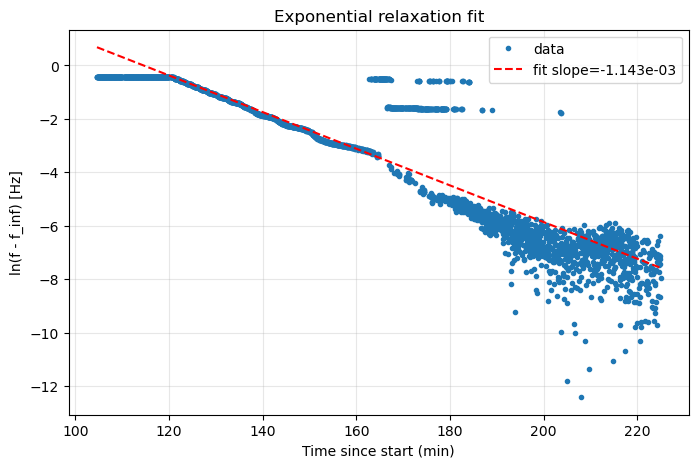

In [54]:
# Convert datetimes to seconds relative to first point
t_win = t_dt    # datetime array (window centers, UTC)
f_win = f_peak

t = np.array([(ti - t_win[0]).total_seconds() for ti in t_win])
f = np.array(f_win)

# Roughly locate the frequency drop (largest negative jump)
df_series = np.diff(f)
j0 = int(np.argmin(df_series))  # index of largest drop
t0 = t[j0+1]

# Estimate final frequency from last ~15 min
late_mask = t >= (t[-1] - 15*60)
f_inf = np.median(f[late_mask])

# Select relaxation region (from a little after the drop until before the flat tail)
relax_mask = (t >= t0 + 2*np.median(np.diff(t))) & (t <= (t[-1] - 15*60))
t_rel = t[relax_mask]
f_rel = f[relax_mask]

# Guard: ensure positivity for log(f - f_inf)
eps = 1e-6
valid = (f_rel - f_inf) > eps
t_rel, f_rel = t_rel[valid], f_rel[valid]

# --- Linearized fit (quick estimate of tau) ---
y = np.log(f_rel - f_inf)
A = np.vstack([t_rel, np.ones_like(t_rel)]).T
m, b = np.linalg.lstsq(A, y, rcond=None)[0]
tau_lin = -1.0/m

# --- Nonlinear fit (cleaner) ---
def relax_model(tt, f0, tau):
    return f_inf + (f0 - f_inf)*np.exp(-(tt - t0)/tau)

p0 = [f[j0+1], tau_lin]  # initial guesses
popt, pcov = curve_fit(relax_model, t_rel, f_rel, p0=p0, maxfev=20000)
f0_fit, tau_nl = popt

print(f"Linearized tau ≈ {tau_lin/60:.2f} min")
print(f"Nonlinear fit tau ≈ {tau_nl/60:.2f} min")

# Derived 'settling times'
print(f"Time to 5% of step: {3*tau_nl/60:.1f} min")
print(f"Time to 1% of step: {4.6*tau_nl/60:.1f} min")

# --- Plot log-linear style (like the paper) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(t_rel/60, np.log(f_rel - f_inf), "o", ms=3, label="data")
plt.plot(t_rel/60, (m*t_rel+b), "r--", label=f"fit slope={m:.3e}")
plt.xlabel("Time since start (min)")
plt.ylabel("ln(f - f_inf) [Hz]")
plt.legend()
plt.title("Exponential relaxation fit")
plt.grid(True, alpha=0.3)
plt.show()

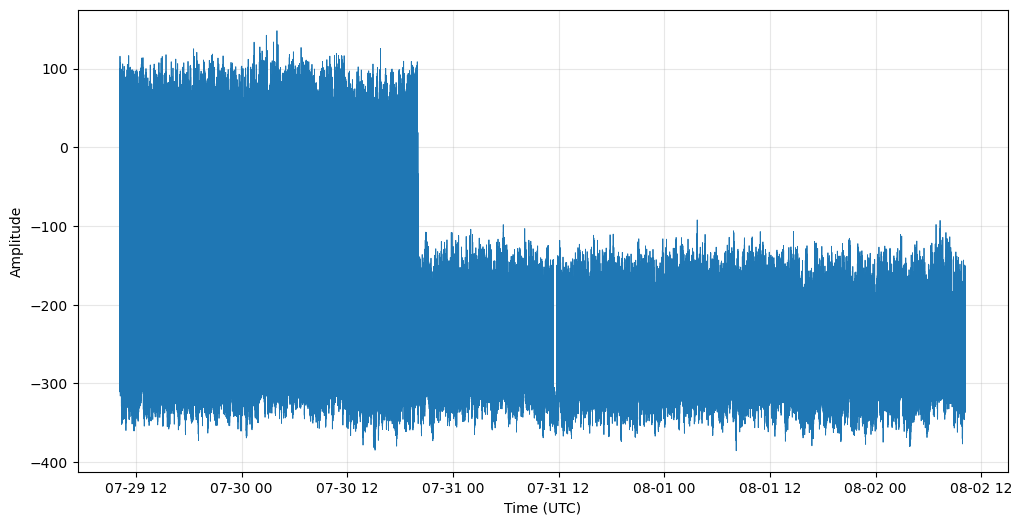

In [24]:
# Dealing with large amounts of raw data by downsampling and gaps in data
# constants
max_points = 200_000 # maximum number of points to plot - change as needed
GPS_UNIX_OFFSET = 315964800 # GPS time offset for UTC conversion

t_plot = []
y_plot = []

with h5py.File(filename, 'r') as f:
    data = f['data']
    segment_starts = f['segments/index_start'][:]
    segment_lengths = f['segments/length'][:]
    gps_times = f['segments/gps_start'][:]
    sample_rate = float(f.attrs['sample_rate'])
    dt = 1.0 / sample_rate
    
    total_samples = int(data.shape[0]) # total number of samples
    step = max(1, total_samples // max_points) # step size for downsampling

    # plot data
    for i in range(len(segment_starts)):
        start = int(segment_starts[i])
        n = int(segment_lengths[i])
        if n <= 0:
            continue
        
        r = (-start) % step # calculate remainder to align with step - where to start sampling
        seg_indices = np.arange(start + r, start + n, step, dtype=np.int64) # keeps consistency across file
        if seg_indices.size == 0:
            continue

        y_seg = data[seg_indices] # extract segment data
        t_seg = gps_times[i] + (seg_indices - start).astype(np.float64) * dt # calculate GPS times

        t_datetime = [datetime.fromtimestamp(tt + GPS_UNIX_OFFSET, tz=timezone.utc)
                     for tt in t_seg] # convert to UTC datetime

        t_plot.extend(t_datetime) # flatten and add to list
        y_plot.extend(y_seg)

# Plot after loading
plt.figure(figsize=(12, 6))
plt.plot(t_plot, y_plot, linewidth=0.6)
plt.xlabel('Time (UTC)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.show()


In [20]:
# deal with time cut
dt_cut_seconds = dt_cut.timestamp() - GPS_UNIX_OFFSET

In [21]:
# real FFT
N = max(1, int(window * fs))  # number of samples in the FFT window
window = np.hanning(N).astype(np.float64)  # Hanning window for the FFT
freqs = np.fft.rfftfreq(N, d=dt)  # frequencies for the FFT
fmin, fmax = band  # frequency band of interest
band_mask = (freqs >= fmin) & (freqs <= fmax)
if not np.any(band_mask):
    raise ValueError(f"Frequency band {band} is out of range for the data (0 to {fs/2} Hz). Adjust the band or window length.")


In [22]:
# Calculate the PSD, sweeping through windows
t_dt = [] # window center times
f_psd = [] # dominant power spectral density frequency

# Load data for PSD calculation
with h5py.File(filename, "r") as f:
    x = f['data']
    for i, n, t0i in zip(idx, length, t0):
        if n < N:
            continue
        if t0i + n * dt < dt_cut_seconds:
            continue
        # read the segment
        n_use = n if (t0i + n * dt) <= dt_cut_seconds else max(0, int(dt_cut_seconds - t0i) // dt) # use only up to the cut-off time
        if n_use < N:
            continue
        n_use = int(n_use)

        # read the segment - no overlapping windows (N), 50% overlap (N//2)
        for j in range(0, n_use - N + 1, N//2):
            y_seg = x[i + j:i + j + N].astype(np.float64) 
            y_seg = (y_seg - np.mean(y_seg)) * window  # apply the window, and get rid of DC offset
            y = np.fft.rfft(y_seg)  # real FFT
            #psd = np.abs(y) ** 2 # power spectral density squared
            psd = (y.real**2 + y.imag**2) # power spectral density squared
            psd = psd[band_mask]  # keep only the band of interest
            if psd.size == 0:
                continue

            k = np.argmax(psd) # index of the peak in the band
            dom_freq = freqs[band_mask][k]

            t_center_gps = t0i + (j + N / 2) * dt
            t_center = datetime.fromtimestamp(t_center_gps + GPS_UNIX_OFFSET, tz=timezone.utc)

            t_dt.append(t_center)
            f_psd.append(dom_freq)


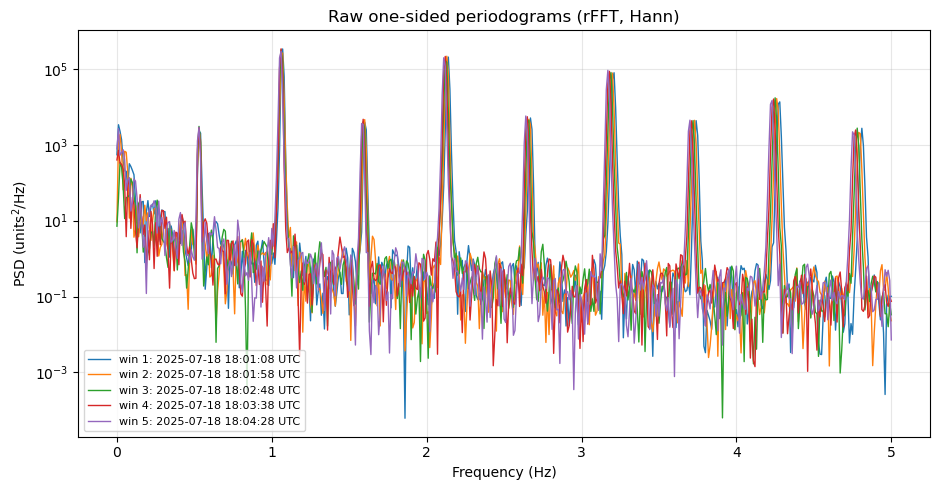

In [53]:
# For stability measurements - overplotted PSDs from different days

d = np.load("raw_psd_first_windows.npz")
freqs = d["freqs"]; P = d["psd"]; t_gps = d["t_center_gps"]; fs = float(d["fs"])
sel = freqs <= 5.0   # e.g., show 0–20 Hz

import matplotlib.pyplot as plt
from datetime import datetime, timezone
GPS_UNIX_OFFSET = 315964800

plt.figure(figsize=(9.5,5))
for k in range(P.shape[0]):
    ts = datetime.fromtimestamp(float(t_gps[k]) + GPS_UNIX_OFFSET, tz=timezone.utc)
    plt.semilogy(freqs[sel], P[k, sel], lw=1.0, label=f"win {k+1}: {ts:%Y-%m-%d %H:%M:%S} UTC")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (units$^2$/Hz)")
plt.title("Raw one-sided periodograms (rFFT, Hann)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

Expected windows up to cutoff: 4075
Collected windows = 4075
[peak 1] median = 0.99748 Hz, MAD = 0.02076 Hz, windows = 4075


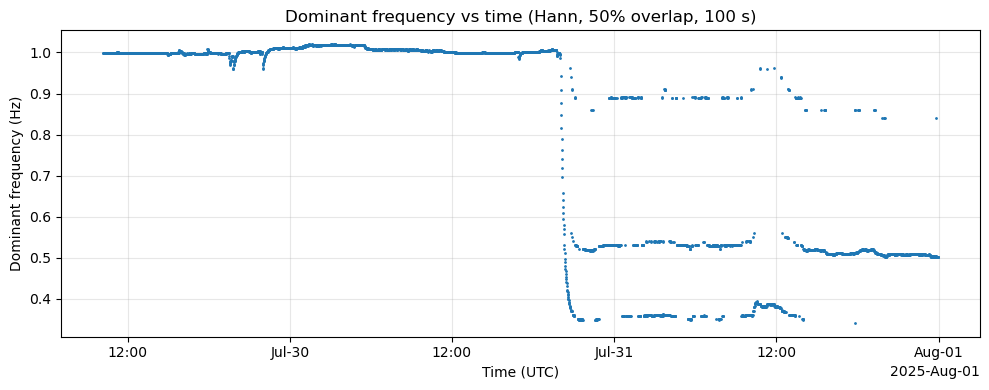

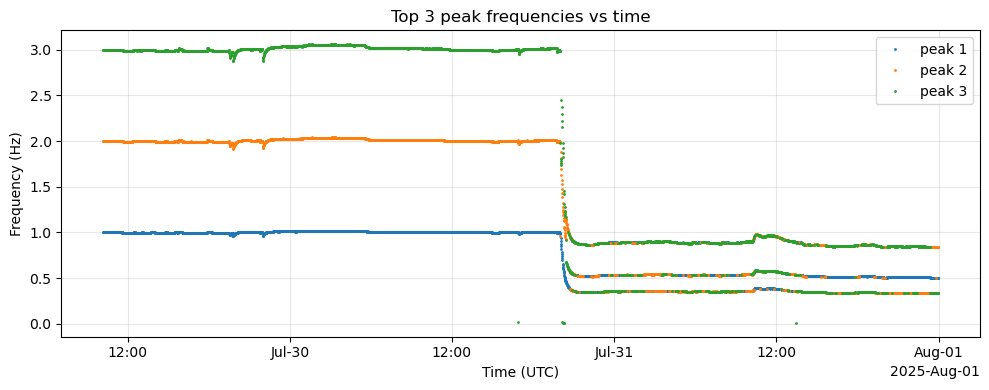

In [ ]:
# For stability measurements - 1st 3 dominant frequencies

# --- window / FFT prep ---
win_sec = 100.0
dt = 1.0 / fs
N    = int(round(win_sec * fs))
step = max(1, int(round(N * (1.0 - overlap)))) # N//2 for 50% overlap
win  = np.hanning(N).astype(np.float64)
freqs = np.fft.rfftfreq(N, d=dt)

fmin, fmax = band
band_mask = (freqs >= fmin) & (freqs <= fmax)
if not np.any(band_mask):
    raise ValueError("Band not on FFT grid; adjust win_sec or band.")
fb = freqs[band_mask] # band-limited axis
df = fb[1] - fb[0] if fb.size > 1 else (freqs[1]-freqs[0])

# top-k config 
top_k = 3
min_sep_hz = 0.03  # require this spacing between peaks
min_sep_bins = max(1, int(round(min_sep_hz / df)))

# crop segments to cutoff and sort by time 
order  = np.argsort(t0)
idx    = idx[order].astype(np.int64)
length = length[order].astype(np.int64)
t0     = t0[order].astype(np.float64)
seg_end = t0 + length * dt

full   = seg_end <= t_cut_gps
idx_use = list(idx[full]); len_use = list(length[full]); t0_use  = list(t0[full])

j = np.searchsorted(t0, t_cut_gps) - 1  # possible straddler
if j >= 0 and seg_end[j] > t_cut_gps:
    n_partial = int(np.floor((t_cut_gps - t0[j]) * fs))
    if n_partial >= N:
        idx_use.append(int(idx[j])); len_use.append(n_partial); t0_use.append(float(t0[j]))

idx_use = np.asarray(idx_use, dtype=np.int64)
len_use = np.asarray(len_use, dtype=np.int64)
t0_use  = np.asarray(t0_use,  dtype=np.float64)

expected = sum(max(0, (int(n) - N) // step + 1) for n in len_use)
print(f"Expected windows up to cutoff: {expected}")

# sweep and collect peaks 
t_dt  = []
F_top = [] # shape -> (W, top_k)

with h5py.File(filename, "r") as f:
    x = f["data"]
    for s, n, t0i in zip(idx_use, len_use, t0_use):
        s = int(s); n = int(n)
        if n < N: continue
        stop = n - N + 1
        for j in range(0, stop, step):
            y = x[s + j : s + j + N].astype(np.float64)
            # if your writer kept NaNs: if not np.all(np.isfinite(y)): continue
            y = (y - y.mean()) * win
            Y = np.fft.rfft(y)
            P = np.abs(Y)**2

            Pb = P[band_mask]
            if Pb.size == 0: 
                continue

            # greedy top-k with min separation + parabolic sub-bin refinement
            cand = np.argsort(Pb)[::-1] # high -> low power
            picks = []
            freqs_top = []
            for k in cand:
                if all(abs(k - kk) >= min_sep_bins for kk in picks):
                    f_est = fb[k]
                    if 0 < k < (Pb.size - 1):
                        a, b, c = Pb[k-1], Pb[k], Pb[k+1]
                        den = (a - 2*b + c)
                        if den != 0.0:
                            f_est = f_est + 0.5*(a - c)/den * df
                    freqs_top.append(float(f_est))
                    picks.append(k)
                    if len(freqs_top) == top_k:
                        break
            # pad with NaN if fewer than top_k found
            while len(freqs_top) < top_k:
                freqs_top.append(np.nan)

            t_center_gps = t0i + (j + 0.5 * N) * dt
            t_dt.append(datetime.fromtimestamp(t_center_gps + GPS_UNIX_OFFSET, tz=timezone.utc))
            F_top.append(freqs_top)

t_dt  = np.array(t_dt, dtype=object)
F_top = np.array(F_top, dtype=float) # (W, 3)
print(f"Collected windows = {len(F_top)}")

# summary (dominant only) 
valid = np.isfinite(F_top[:,0])
if np.any(valid):
    f0 = F_top[valid,0]
    med = np.median(f0); mad = np.median(np.abs(f0 - med))
    print(f"[peak 1] median = {med:.5f} Hz, MAD = {mad:.5f} Hz, windows = {f0.size}")
else:
    print("No windows analyzed.")

# plots
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(t_dt, F_top[:,0], ".", markersize=2)
ax.set_ylabel("Dominant frequency (Hz)"); ax.set_xlabel("Time (UTC)")
loc = mdates.AutoDateLocator(minticks=6, maxticks=12)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc, tz=timezone.utc))
ax.grid(True, alpha=0.3)
ax.set_title(f"Dominant frequency vs time (Hann, {int(overlap*100)}% overlap, {int(win_sec)} s)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10,4))
labels = ["peak 1","peak 2","peak 3"]
for k in range(top_k):
    ax.plot(t_dt, F_top[:,k], ".", markersize=2, label=labels[k])
ax.legend(); ax.set_ylabel("Frequency (Hz)"); ax.set_xlabel("Time (UTC)")
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc, tz=timezone.utc))
ax.grid(True, alpha=0.3)
ax.set_title("Top 3 peak frequencies vs time")
plt.tight_layout(); plt.show()


Collected PSDs for 4 day(s).


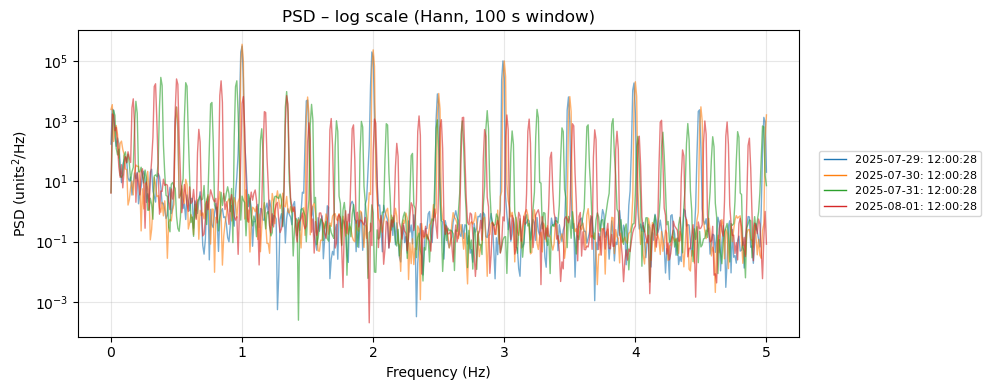

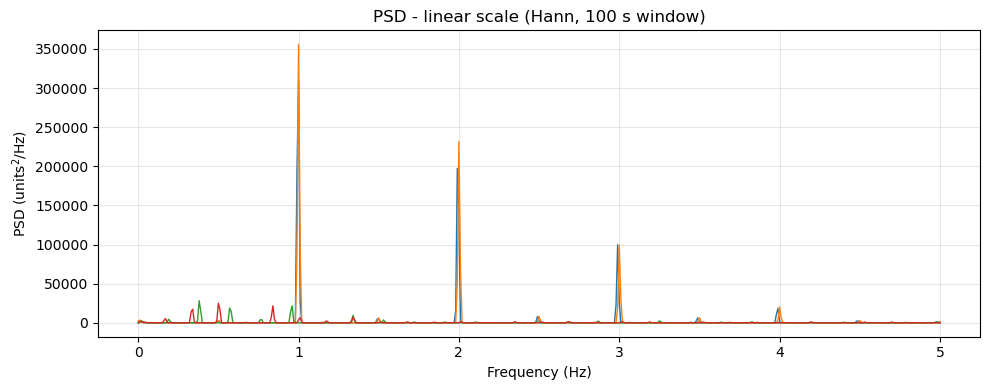

In [31]:
import h5py, numpy as np, matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta

# --- inputs ---
#filename   = "data/Y1_RDS-LES_YAW_MON_OUT_DQ_1437929734_1437965734.h5"  # your file
win_sec    = 100.0          # seconds per PSD window (Δf ≈ 1/win_sec)
fmax_plot  = 5.0            # Hz, x-axis limit for the plots
start_day  = datetime(2025, 7, 29, 12, 0, tzinfo=timezone.utc)
end_day    = datetime(2025, 8, 1, 12, 0, tzinfo=timezone.utc)  # inclusive list ends at this day
GPS_UNIX_OFFSET = 315964800

# --- helper: datetimes → GPS seconds (UTC) ---
def dt_to_gps(dt):
    return dt.timestamp() - GPS_UNIX_OFFSET

# --- load segments + fs ---
with h5py.File(filename, "r") as f:
    idx = f["segments/index_start"][:].astype(np.int64)
    lng = f["segments/length"][:].astype(np.int64)
    t0  = f["segments/gps_start"][:].astype(np.float64)
    fs  = float(f.attrs["sample_rate"])
dt = 1.0 / fs

# sort by start time (important)
order = np.argsort(t0)
idx, lng, t0 = idx[order], lng[order], t0[order]
seg_end = t0 + lng * dt

# FFT/PSD setup
N    = int(round(win_sec * fs))
win  = np.hanning(N).astype(np.float64)
win_pow_sum = np.sum(win**2)
freqs = np.fft.rfftfreq(N, d=dt)

# prepare the day list
days = []
d = start_day
while d <= end_day:
    days.append(d)
    d += timedelta(days=1)

# collect PSDs
label_used = []      # label strings for legend
psd_rows   = []      # one PSD row per day (full 0..fs/2)
used_times = []      # actual UTC time used (might be a bit after midnight if midnight is in a gap)

with h5py.File(filename, "r") as f:
    x = f["data"]

    for day_dt in days:
        t_mid = dt_to_gps(day_dt)

        # find segment that contains midnight
        i = np.searchsorted(t0, t_mid) - 1
        found = False

        # Case A: midnight falls inside a segment; try to start at midnight if remainder fits
        if 0 <= i < len(t0) and (t0[i] <= t_mid < seg_end[i]):
            offset = int(np.floor((t_mid - t0[i]) * fs))
            if offset + N <= int(lng[i]):
                s = int(idx[i] + offset)
                t_start_gps = t_mid
                found = True

        # Case B: otherwise, use the earliest *later* segment that can hold a full window
        if not found:
            j = np.searchsorted(t0, t_mid)
            while j < len(t0) and int(lng[j]) < N:
                j += 1
            if j < len(t0):
                s = int(idx[j])                 # start at that segment's beginning
                t_start_gps = float(t0[j])
                found = True

        if not found:
            # no data that day
            print(f"[skip] No contiguous {win_sec:.0f}s window on {day_dt.date()} (UTC).")
            continue

        # read samples and compute PSD
        y = x[s : s + N].astype(np.float64)
        # if you kept NaNs in writer, you may want: if not np.all(np.isfinite(y)): continue
        y = (y - y.mean()) * win
        Y = np.fft.rfft(y)
        S = (np.abs(Y)**2) / (fs * win_pow_sum)
        if S.size > 2:
            S[1:-1] *= 2.0                      # one-sided correction

        psd_rows.append(S)
        used_times.append(datetime.fromtimestamp(t_start_gps + GPS_UNIX_OFFSET, tz=timezone.utc))
        label_used.append(f"{day_dt:%Y-%m-%d}: {used_times[-1].strftime('%H:%M:%S')}")

# stack to array
if not psd_rows:
    raise RuntimeError("No PSDs were collected for the requested days.")
P = np.vstack(psd_rows)   # shape (num_days_found, N//2+1)
print(f"Collected PSDs for {P.shape[0]} day(s).")

# --- plots ---
sel = freqs <= fmax_plot

# semilogy
fig, ax = plt.subplots(figsize=(10,4))
for k in range(P.shape[0]):
    ax.semilogy(freqs[sel], P[k, sel], lw=1.0, alpha=0.6, label=label_used[k])  # alpha helps
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("PSD (units$^2$/Hz)")
ax.set_title(f"PSD – log scale (Hann, {int(win_sec)} s window)")
ax.grid(True, alpha=0.3)

# put legend outside right, and make room
leg = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=8)
for lh in leg.legend_handles:  # keep legend lines opaque if you want
    lh.set_alpha(1.0)
plt.subplots_adjust(right=0.78)  # space for the legend
plt.tight_layout()
plt.show()

# linear
plt.figure(figsize=(10,4))
for k in range(P.shape[0]):
    plt.plot(freqs[sel], P[k, sel], lw=1.0, label=label_used[k])
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (units$^2$/Hz)")
plt.title(f"PSD - linear scale (Hann, {int(win_sec)} s window)")
plt.grid(True, alpha=0.3)
#plt.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()


### For hdf5 files created from nds2 fetch function

In [5]:
with h5py.File(filename, "r") as f:
    data = f["data"][:] # raw samples
    print('len(data):', len(data))
    timestamps = f["timestamps"][:] # GPS‐based times
    print('len(timestamps):', len(timestamps))

len(data): 88473600
len(timestamps): 88473600


In [6]:
# convert GPS times to UTC datetime objects
gps_epoch = datetime(1980, 1, 6)
times_utc = [gps_epoch + timedelta(seconds=ts) for ts in timestamps]
print('len(times_utc):', len(times_utc))

len(times_utc): 88473600


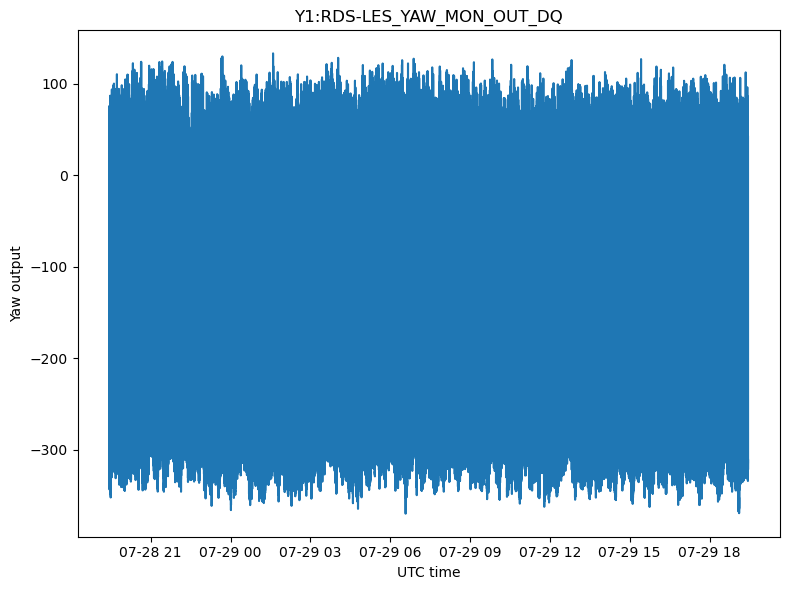

In [7]:
# downsampling raw data to reduce plot size
max_points = int(1e5)
step = max(1, len(data) // max_points)
tsampled_data = data[::step]
tsampled_times = times_utc[::step]

plt.figure(figsize=(8, 6))
plt.plot(tsampled_times, tsampled_data)
plt.xlabel("UTC time")
plt.ylabel("Yaw output")
plt.title("Y1:RDS-LES_YAW_MON_OUT_DQ")
plt.tight_layout()

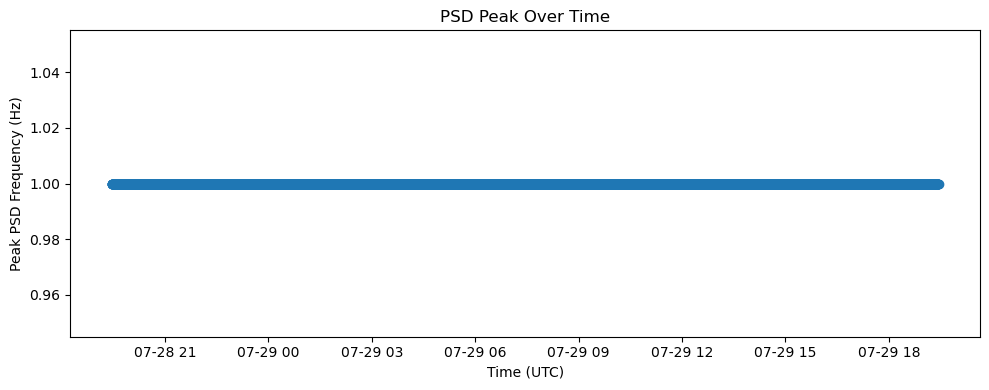

In [ ]:
fs = 1024 # sampling rate of file (Hz)
seg_secs = 16 # window length in seconds
nperseg =  2**15 # window length in samples (~16s at 1024Hz)
band = (0.1, 5) # frequency band of interest (Hz)
noverlap = nperseg // 2  # 50% overlap -- default for Welch method

peak_times = []
peak_freqs = []

step = nperseg - noverlap
for start in range(0, len(data) - nperseg + 1, step):
    segment      = data[start : start + nperseg]
    time_segment = times_utc[start : start + nperseg]

    # Use Welch PSD like before
    f, Pxx = welch(segment, fs=fs, nperseg=nperseg, noverlap=noverlap)

    idx_peak = np.argmax(Pxx)
    peak_freqs.append(f[idx_peak])

    t_mid = time_segment[0] + (time_segment[-1] - time_segment[0]) / 2
    peak_times.append(t_mid)


plt.figure(figsize=(10,4))
plt.plot(peak_times, peak_freqs, marker='o', linestyle='-')
plt.xlabel("Time (UTC)")
plt.ylabel("Peak PSD Frequency (Hz)")
plt.title("PSD Peak Over Time")
plt.tight_layout()
plt.show()

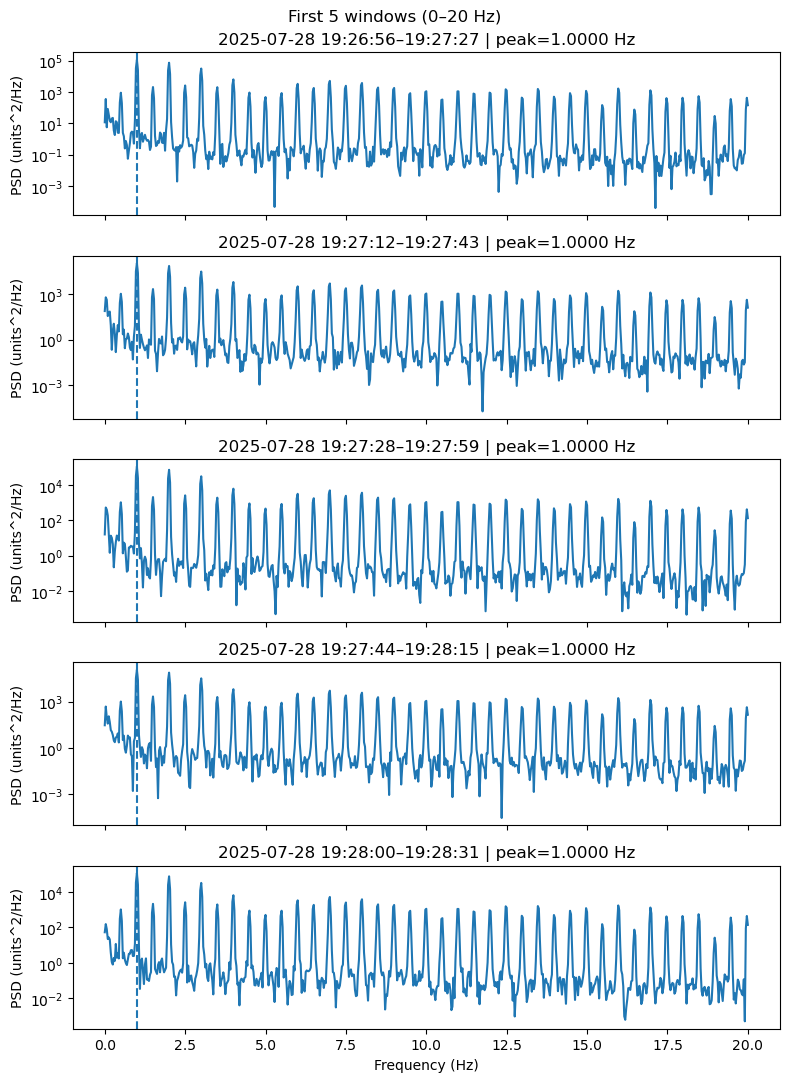

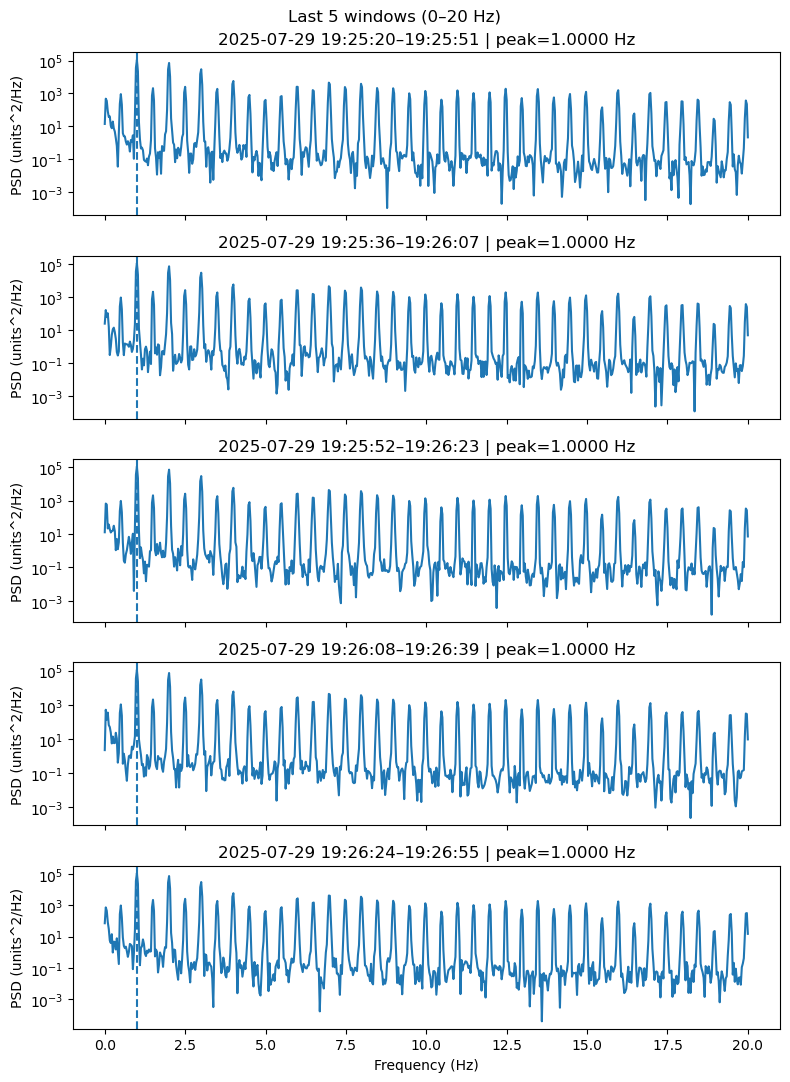

In [23]:
# Plot the first and last few windows to visualize the PSDs and see the peak frequencies.
# Uses Hanning window and 50% overlap.
def plot_chunk_psds(data, times_utc, fs, nperseg, noverlap, title, starts):
    n = len(starts)
    if n == 0:
        print("No windows to plot.")
        return
    fig, axes = plt.subplots(n, 1, figsize=(8, 2.2*n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, start in zip(axes, starts):
        seg = data[start:start+nperseg]
        seg = seg - np.mean(seg)

        f, Pxx = welch(
            seg, fs=fs,
            nperseg=nperseg, noverlap=0, detrend=False
        )

        sel = (f >= 0.0) & (f <= 20.0)   # 0–20 Hz band for plotting
        fb, Pb = f[sel], Pxx[sel]
        k = np.argmax(Pb)
        fpk = fb[k]

        t0 = times_utc[start]
        t1 = times_utc[start + nperseg - 1]

        ax.semilogy(fb, Pb)
        ax.axvline(fpk, ls="--")
        ax.set_ylabel("PSD (units^2/Hz)")
        ax.set_title(f"{t0:%Y-%m-%d %H:%M:%S}–{t1:%H:%M:%S} | peak={fpk:.4f} Hz")

    axes[-1].set_xlabel("Frequency (Hz)")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

step = nperseg - noverlap
starts_all = np.arange(0, len(data) - nperseg + 1, step)

first5 = starts_all[:min(5, len(starts_all))]
last5  = starts_all[-min(5, len(starts_all)):] if len(starts_all) else starts_all

plot_chunk_psds(data, times_utc, fs, nperseg, noverlap,
                f"First {len(first5)} windows (0–20 Hz)", first5)

plot_chunk_psds(data, times_utc, fs, nperseg, noverlap,
                f"Last {len(last5)} windows (0–20 Hz)", last5)

### For hdf5 files created from ndscope GUI

In [47]:
# Open the HDF5 file and explore its structure
with h5py.File(filename, "r") as f:
    # List all top-level keys
    for key in f.keys():
        print("Top-level key:", key)

    # Try accessing time-series for one channel
    group = f['Y1:RDS-LES_PIT_MON_OUT_DQ']
    print("Subkeys in group:", list(group.keys()))

    # Check if there's a dataset like 'value' or 'data':
    if 'value' in group:
        values = group['value'][:]
        times = group['time'][:] if 'time' in group else range(len(values))

        plt.plot(times, values)
        plt.xlabel("Time")
        plt.ylabel("PIT Monitor Output")
        plt.title("Y1:RDS-LES_PIT_MON_OUT_DQ")
        plt.show()

Top-level key: Y1:RDS-LES_PIT_MON_OUT_DQ
Top-level key: Y1:RDS-LES_YAW_MON_OUT_DQ
Subkeys in group: ['max', 'mean', 'min']


In [ ]:
with h5py.File(filename, "r") as f:
    group = f["Y1:RDS-LES_YAW_MON_OUT_DQ"]

    # List datasets or subgroups (max/mean/min)
    print("Keys in group:", list(group.keys()))

    # Is there a time dataset?
    if 'time' in group:
        print("Found time dataset")
    else:
        print("No time dataset found in group")

    # Check for attributes that might include time info
    print("Attributes in group:")
    for key, val in group.attrs.items():
        try:
            print(f"  {key}: {val} (length: {len(val)})")
        except TypeError:
            print(f"  {key}: {val} (scalar)")

    print("Dataset lengths:")
    for key in group.keys():
        dset = group[key]
        print(f"  {key}: length = {len(dset)}")

Keys in group: ['max', 'mean', 'min']
No time dataset found in group
Attributes in group:
  gps_start: 1437933626.0 (scalar)
  sample_rate: 1.0 (scalar)
  unit: undef (length: 5)
Dataset lengths:
  max: length = 6178
  mean: length = 6178
  min: length = 6178


In [49]:
# Print out arrays of the HDF5 file
with h5py.File(filename, "r") as f:
    for channel in f.keys():
        print(f"Channel: {channel}")
        for stat in f[channel].keys():
            value = f[channel][stat][()]
            print(f"  {stat}: {value}")

Channel: Y1:RDS-LES_PIT_MON_OUT_DQ
  max: [1307.5461 1305.189  1307.5901 ... 1285.1171 1286.1821 1289.2893]
  mean: [1268.85992801 1260.97233427 1265.7868135  ... 1237.64676404 1249.5353663
 1241.22475386]
  min: [1096.3954 1095.9692 1093.4061 ... 1074.267  1077.8939 1075.8872]
Channel: Y1:RDS-LES_YAW_MON_OUT_DQ
  max: [ 77.45194   82.686905  82.890854 ... 104.52109  110.29568  105.40498 ]
  mean: [-279.27052411 -265.41098268 -268.46944672 ... -235.43653797 -248.75060261
 -236.89464712]
  min: [-341.26227 -336.53668 -327.62125 ... -309.35223 -310.03217 -310.60504]


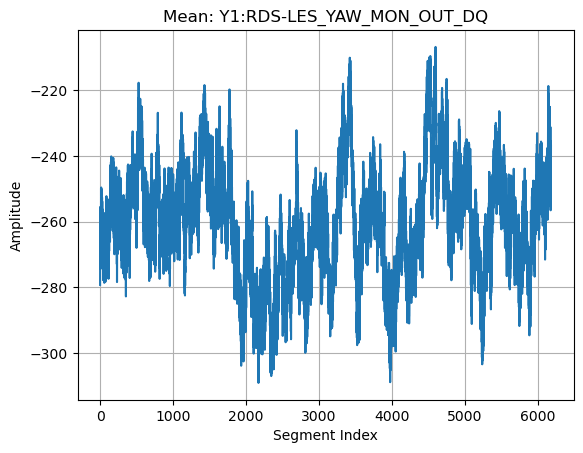

In [ ]:
# plot the mean
with h5py.File(filename, "r") as f:
    mean_pit = f["Y1:RDS-LES_YAW_MON_OUT_DQ/mean"][:]
    plt.plot(mean_pit)
    plt.title("Mean: Y1:RDS-LES_YAW_MON_OUT_DQ")
    plt.ylabel("Amplitude")
    plt.xlabel("Segment Index")
    plt.grid()
    plt.show()

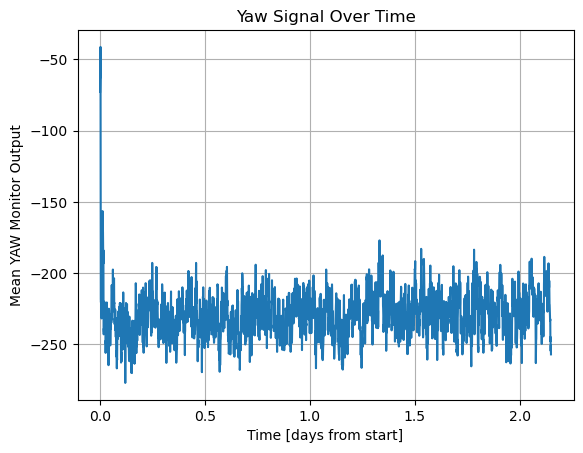

In [ ]:
with h5py.File(filename, "r") as f:
    group = f["Y1:RDS-LES_YAW_MON_OUT_DQ"]
    mean_yaw = group["mean"][:]
    sample_rate = group.attrs["sample_rate"]
    gps_start = group.attrs["gps_start"]

    # Remove NaN values
    valid_idx = ~np.isnan(mean_yaw)
    mean_yaw = mean_yaw[valid_idx]

    # Reconstruct time array
    dt = 1.0 / sample_rate  # seconds per sample (60.0)
    time_gps = np.arange(len(mean_yaw)) * dt + gps_start
    time_days = (time_gps - gps_start) / (60 * 60 * 24)  # time in days from start

plt.plot(time_days, mean_yaw)
plt.xlabel("Time [days from start]")
plt.ylabel("Mean YAW Monitor Output")
plt.title("Yaw Signal Over Time")
plt.grid()
plt.show()

In [24]:
# GPS epoch is 1980-01-06
gps_epoch = datetime(1980, 1, 6)

# Reconstruct datetime array
time_dt = [gps_epoch + timedelta(seconds=t) for t in time_gps]

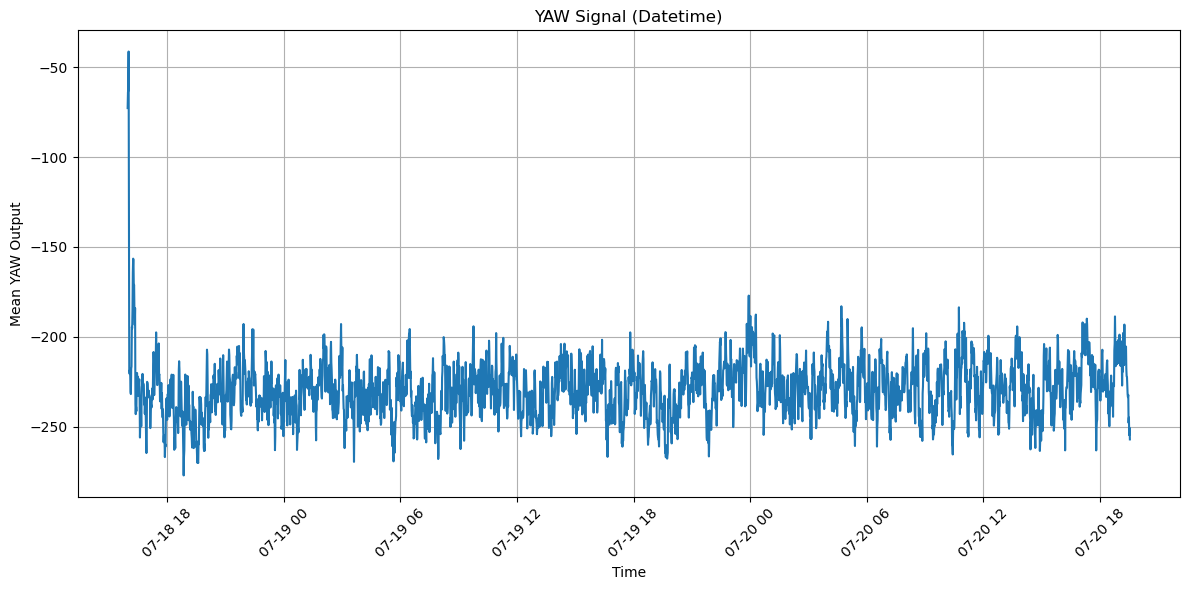

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(time_dt, mean_yaw)
plt.xlabel("Time")
plt.ylabel("Mean YAW Output")
plt.title("YAW Signal (Datetime)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
fs = 1 / 60.0  # Hz (1 sample per 60 seconds -- this will change based on data extraction)
window_size = 180  # samples = 3 hours
overlap = 90       # samples = 50% overlap

dominant_freqs = []
time_stamps = []

for i in range(0, len(mean_yaw) - window_size + 1, window_size - overlap):
    chunk = mean_yaw[i:i + window_size]
    t_center = time_dt[i + window_size // 2]

    if np.isnan(chunk).any():
        continue

    f, Pxx = welch(chunk, fs=fs, nperseg=window_size)
    peak_freq = f[np.argmax(Pxx)]
    dominant_freqs.append(peak_freq)
    time_stamps.append(t_center)

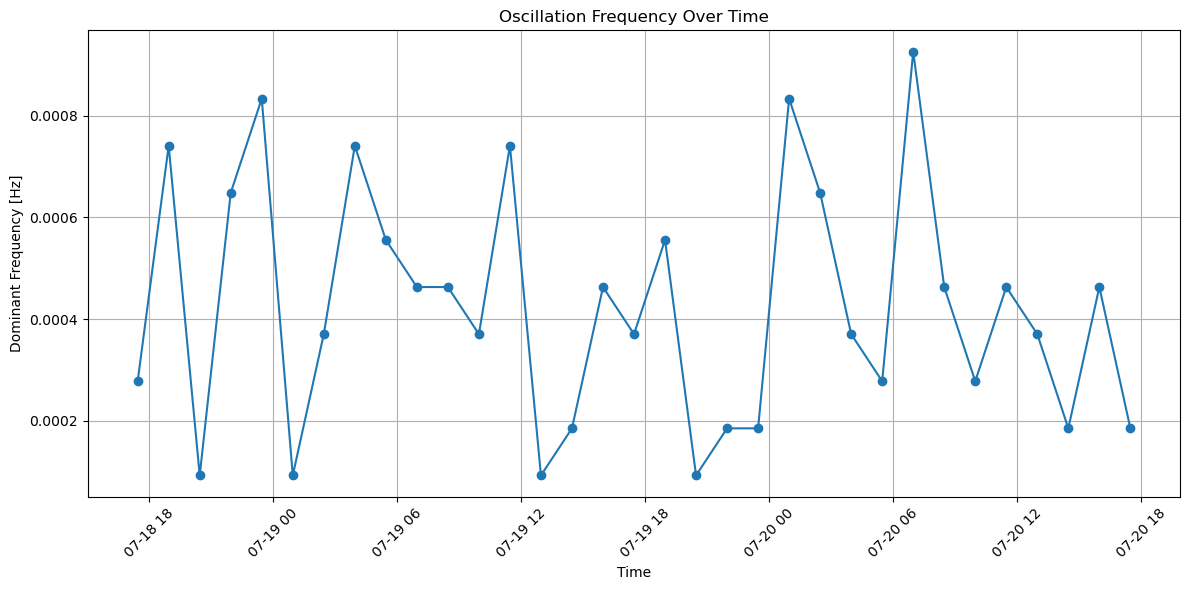

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(time_stamps, dominant_freqs, marker='o')
plt.xlabel("Time")
plt.ylabel("Dominant Frequency [Hz]")
plt.title("Oscillation Frequency Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()